In [54]:
# Quasi-degenerate
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, IAXOplus, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

q0 = 9.0 # 3-sigma discovery limit
m2 = 1e-3 # [eV]
g_arb = 1.0e-11 # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
res_on = True


delta_m21_sq_vals = np.logspace(-18.0,np.log10(4e-10),1000) # [eV^2]
x = np.sqrt(delta_m21_sq_vals)
g_disc_IAXO_10eV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_100eV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_200eV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXOplus_10eV = np.empty_like(delta_m21_sq_vals,dtype=float)

N_bins = 2000
w_res = 10e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXO_10eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                          w_min,w_max,N_bins,
                                          res_on=res_on,w_res=w_res,
                                          m2_bounds=(m2,m2))
N_bins = 200
w_res = 100e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXO_100eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                           w_min,w_max,N_bins,
                                           res_on=res_on,w_res=w_res,
                                           m2_bounds=(m2,m2))

N_bins = 100
w_res = 200e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXO_200eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                           w_min,w_max,N_bins,
                                           res_on=res_on,w_res=w_res,
                                           m2_bounds=(m2,m2))

N_bins = 2000
w_res = 10e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXOplus_10eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXOplus["B"],IAXOplus["L"],L_source,IAXOplus["S"],IAXOplus["t"],IAXOplus["eps_T"],IAXOplus["eps_D"],
                                              w_min,w_max,N_bins,
                                              res_on=res_on,w_res=w_res,
                                              m2_bounds=(m2,m2))

np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXO_disc_10eV.dat",
           np.column_stack((x,g_disc_IAXO_10eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 10 eV)")

np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXO_disc_100eV.dat",
           np.column_stack((x,g_disc_IAXO_100eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")

np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXO_disc_200eV.dat",
           np.column_stack((x,g_disc_IAXO_200eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 200 eV)")

np.savetxt("results_data/Quasi-degenerate/Quasideg_IAXOplus_disc_10eV.dat",
           np.column_stack((x,g_disc_IAXOplus_10eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXOplus [GeV^-1]    (varphi = pi/4, w_res = 10 eV)")


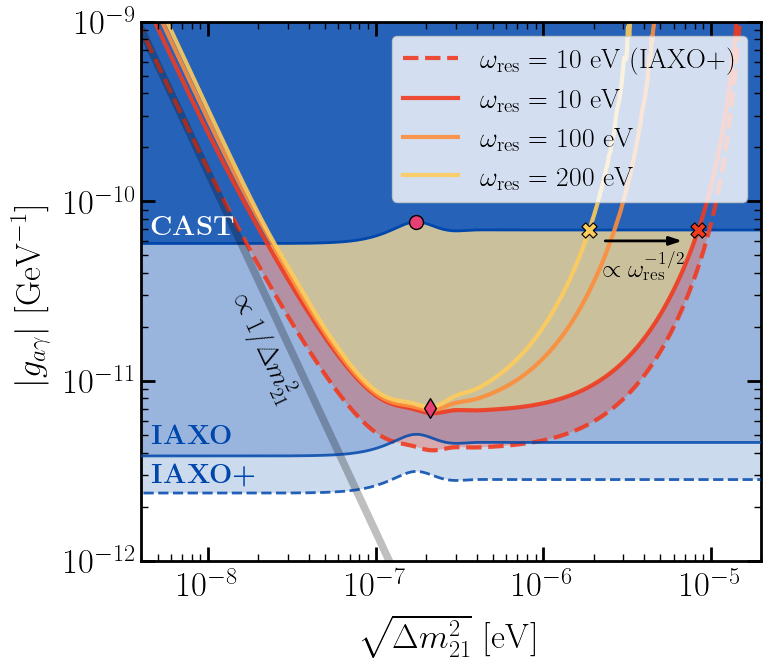

In [2]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":25,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

gs = gridspec.GridSpec(1,1,wspace=0.0)
fig = plt.figure()
ax = fig.add_subplot(gs[0])
ax.set_xlim(left=4e-9,right=2e-5)
ax.set_ylim(bottom=1e-12,top=1e-9)
ax.tick_params(axis='x',which='major',pad=8)
ax.tick_params(axis='x',which='minor',pad=8)
ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$",labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$",labelpad=10)

folder1 = "input_data"
folder2 = "results_data"
reds = YlOrRd_5.mpl_colors
bolds = Bold_10.mpl_colors

# Exclusion limit CAST @95 CL
CAST = np.loadtxt(os.path.join(folder1,"CAST_exclusion.dat"))
x_CAST = CAST[:,0]
g_excl_CAST = CAST[:,1]
plt.loglog(x_CAST,g_excl_CAST,color="#0047AB",zorder=1)
ax.fill_between(x_CAST,g_excl_CAST,ax.get_ylim()[1],facecolor="#0047AB",zorder=0.5,alpha=0.85)
ax.text(4.56e-9,6.5e-11,r'{\bf CAST}',fontsize=20,color='w',zorder=1000)

# Exclusion limit IAXO @95 CL
IAXO = np.loadtxt(os.path.join(folder1,"IAXO_projection.dat"))
x_IAXO = IAXO[:,0]
g_excl_IAXO = IAXO[:,1]
plt.loglog(x_IAXO,g_excl_IAXO,color="#0047AB",zorder=8,alpha=0.85)
ax.fill_between(x_IAXO,g_excl_IAXO,g_excl_CAST,facecolor="#0047AB",zorder=0.05,alpha=0.4)
ax.text(4.56e-9,4.5e-12,r'{\bf IAXO}',fontsize=20,color="#0047AB",zorder=1000)

# Exclusion limit IAXOplus @95 CL
IAXOplus = np.loadtxt(os.path.join(folder1,"IAXOplus_projection.dat"))
x_IAXOplus = IAXOplus[:,0]
g_excl_IAXOplus = IAXOplus[:,1]
plt.loglog(x_IAXOplus,g_excl_IAXOplus,color="#0047AB",ls='--',zorder=8,alpha=0.85)
ax.fill_between(x_IAXOplus,g_excl_IAXOplus,g_excl_IAXO,facecolor="#0047AB",zorder=0.05,alpha=0.2)
ax.text(4.56e-9,2.7e-12,r'{\bf IAXO+}',fontsize=20,color="#0047AB",zorder=1000)

# Discovery limit IAXOplus (w_res = 10 eV)
IAXOplus_10eV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXOplus_disc_10eV.dat"))
x_IAXOplus_10eV = IAXOplus_10eV[:,0]
g_disc_IAXOplus_10eV = IAXOplus_10eV[:,1]
plt.loglog(x_IAXOplus_10eV,g_disc_IAXOplus_10eV,color=reds[3],lw=3,ls='--',label=r'$\omega_\mathrm{res} = 10\ \mathrm{eV}\ (\mathrm{IAXO}+)$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 10 eV)
IAXO_10eV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXO_disc_10eV.dat"))
x_IAXO_10eV = IAXO_10eV[:,0]
g_disc_IAXO_10eV = IAXO_10eV[:,1]
plt.loglog(x_IAXO_10eV,g_disc_IAXO_10eV,color=reds[3],lw=3,label=r'$\omega_\mathrm{res} = 10\ \mathrm{eV}$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 100 eV)
IAXO_100eV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXO_disc_100eV.dat"))
x_IAXO_100eV = IAXO_100eV[:,0]
g_disc_IAXO_100eV = IAXO_100eV[:,1]
plt.loglog(x_IAXO_100eV,g_disc_IAXO_100eV,color=reds[2],lw=3,label=r'$\omega_\mathrm{res} = 100\ \mathrm{eV}$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 200 eV)
IAXO_200eV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","Quasideg_IAXO_disc_200eV.dat"))
x_IAXO_200eV = IAXO_200eV[:,0]
g_disc_IAXO_200eV = IAXO_200eV[:,1]
plt.loglog(x_IAXO_200eV,g_disc_IAXO_200eV,color=reds[1],lw=3,label=r'$\omega_\mathrm{res} = 200\ \mathrm{eV}$',zorder=2,alpha=0.9)

# Relevant points
x1_val = 1.75e-7 # [eV]
y1_val = 7.67218e-11 # [GeV^-1]
ax.scatter(x1_val,y1_val,color=bolds[4],s=100,zorder=50,marker='o',edgecolor='black')
x2_val = 2.12e-7 # [eV]
y2_val = 7.04e-12 # [GeV^-1]
ax.scatter(x2_val,y2_val,color=bolds[4],s=100,zorder=50,marker='d',edgecolor='black')

# Resolution effect
g_CAST_level = 6.932781e-11  # [GeV^-1]
cross_200 = 1.88059e-6 # [eV] 
cross_100 = 2.6595e-6 # [eV]
cross_10  = 8.41149e-6 # [eV]
ax.scatter(cross_200,g_CAST_level,color=reds[1],s=120,zorder=55,marker='X',edgecolor='k',linewidths=0.8)
ax.scatter(cross_10,g_CAST_level,color=reds[3],s=120,zorder=55,marker='X',edgecolor='k',linewidths=0.8)
ax.annotate('',xy=(cross_10/1.2, g_CAST_level/1.15),
            xytext=(cross_200*1.2, g_CAST_level/1.15),
            arrowprops=dict(arrowstyle='-|>,head_length=0.3,head_width=0.1',color='k',lw=2),
            zorder=60)
ax.text(np.sqrt(cross_200*cross_10),g_CAST_level/1.95,r'$\propto \omega_{\rm res}^{-1/2}$',fontsize=18,ha='center',va='bottom',color='k',zorder=60)

# Reference line g ~ 1/Dm2^2
m_ref_start = x_IAXOplus_10eV[0]
g_ref_start = g_disc_IAXOplus_10eV[0]
m_ref_end = x_IAXOplus_10eV[-1]
g_ref_end = g_ref_start*(m_ref_start/m_ref_end)**2
ax.loglog([m_ref_start,m_ref_end],[g_ref_start,g_ref_end],'k-',lw=5.5,alpha=0.25)
ax.text(1.3e-8,1.3e-11/1.7,r'$ \propto 1/\Delta m_{21}^{2}$',fontsize=20,color="k",zorder=1000,rotation=-65)

# Distinction regions
logg_CAST_on_IAXO_10eV = np.interp(np.log10(x_IAXO_10eV),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_IAXO_10eV = 10**logg_CAST_on_IAXO_10eV
mask = g_CAST_on_IAXO_10eV > g_disc_IAXO_10eV
ax.fill_between(
    x_IAXO_10eV,
    g_disc_IAXO_10eV,
    g_CAST_on_IAXO_10eV,
    where=mask,
    facecolor=reds[1],
    interpolate=True,
    alpha=0.5,
    zorder=0.1           
)

def interp_loglog(x_new,x,y):
    return 10**np.interp(np.log10(x_new),np.log10(x),np.log10(y))
xmin = max(x_CAST.min(),x_IAXO_10eV.min(),x_IAXOplus_10eV.min())
xmax = min(x_CAST.max(),x_IAXO_10eV.max(),x_IAXOplus_10eV.max())
x_common = np.logspace(np.log10(xmin),np.log10(xmax),2000)
gCAST = interp_loglog(x_common,x_CAST,g_excl_CAST)
gIAXO = interp_loglog(x_common,x_IAXO_10eV,g_disc_IAXO_10eV)
gIAXOp = interp_loglog(x_common,x_IAXOplus_10eV,g_disc_IAXOplus_10eV)
g_bottom = np.minimum(gIAXO,gIAXOp)
g_top = np.minimum(gIAXO,gCAST)
mask = g_top > g_bottom
ax.fill_between(
    x_common,
    g_bottom,
    g_top,
    where=mask,
    interpolate=True,
    facecolor=reds[3],
    alpha=0.3,
    zorder=0.3
)

ax.xaxis.set_zorder(1000)
ax.yaxis.set_zorder(1000)
leg = ax.legend(fontsize=20,loc='upper right')
leg.set_zorder(2000)

fig.savefig("plots/Quasi-degenerate_disc.pdf",bbox_inches="tight")
fig.savefig("plots/Quasi-degenerate_disc.png",bbox_inches="tight")
plt.show()

In [48]:
# SN
import numpy as np
from Functions_Binned_Analysis import SN_Discovery_Limit, IAXO, IAXOplus, L_SN
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

g_aN = 1.3e-9
delta = 1.0
q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11 # [GeV^-1]
m2 = 1e-1 # [eV]
mixing = np.pi/4.0
L_source = L_SN
eps = 0.95
w_min = 0.0 # [MeV]
w_max = 1000.0 # [MeV]
res_on = True

delta_m21_sq_vals = np.logspace(np.log10(1e-18),np.log10(4e-14),1000) # [eV^2]
x = np.sqrt(delta_m21_sq_vals)
g_disc_IAXO_04MeV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_1MeV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_2MeV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXOplus_04MeV = np.empty_like(delta_m21_sq_vals,dtype=float)

N_bins = 2500
w_res = 0.4 # [MeV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXO_04MeV[k] = SN_Discovery_Limit(g_aN,delta,q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],eps,
                                             w_min,w_max,N_bins,
                                             res_on=res_on,w_res=w_res,
                                             m2_bounds=(m2,m2))

N_bins = 1000
w_res = 1 # [MeV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXO_1MeV[k] = SN_Discovery_Limit(g_aN,delta,q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],eps,
                                             w_min,w_max,N_bins,
                                             res_on=res_on,w_res=w_res,
                                             m2_bounds=(m2,m2))

N_bins = 500
w_res = 2 # [MeV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXO_2MeV[k] = SN_Discovery_Limit(g_aN,delta,q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],eps,
                                             w_min,w_max,N_bins,
                                             res_on=res_on,w_res=w_res,
                                             m2_bounds=(m2,m2))
N_bins = 2500
w_res = 0.4 # [MeV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_IAXOplus_04MeV[k] = SN_Discovery_Limit(g_aN,delta,q0,g_arb,m2,dm2,mixing,IAXOplus["B"],IAXOplus["L"],L_source,IAXOplus["S"],eps,
                                                  w_min,w_max,N_bins,
                                                  res_on=res_on,w_res=w_res,
                                                  m2_bounds=(m2,m2))

np.savetxt("results_data/Quasi-degenerate/SN_Quasideg_IAXO_disc_04MeV.dat",
           np.column_stack((x,g_disc_IAXO_04MeV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 0.4 MeV)")

np.savetxt("results_data/Quasi-degenerate/SN_Quasideg_IAXO_disc_1MeV.dat",
           np.column_stack((x,g_disc_IAXO_1MeV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 1 MeV)")

np.savetxt("results_data/Quasi-degenerate/SN_Quasideg_IAXO_disc_2MeV.dat",
           np.column_stack((x,g_disc_IAXO_2MeV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 2 MeV)")

np.savetxt("results_data/Quasi-degenerate/SN_Quasideg_IAXOplus_disc_04MeV.dat",
           np.column_stack((x,g_disc_IAXOplus_04MeV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXOplus [GeV^-1]    (varphi = pi/4, w_res = 0.4 MeV)")

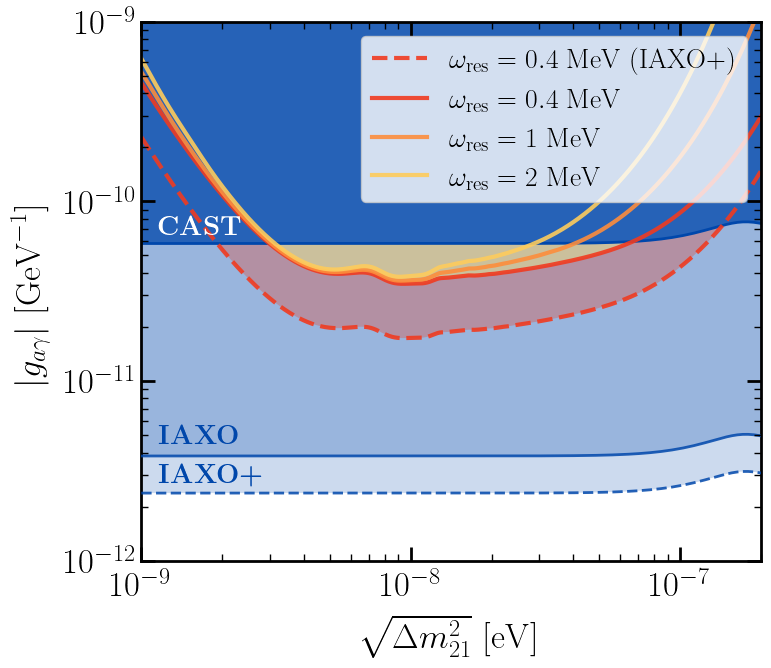

In [4]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":25,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

gs = gridspec.GridSpec(1,1,wspace=0.0)
fig = plt.figure()
ax = fig.add_subplot(gs[0])
ax.set_xlim(left=1e-9,right=2e-7)
ax.set_ylim(bottom=1e-12,top=1e-9)
ax.tick_params(axis='x',which='major',pad=8)
ax.tick_params(axis='x',which='minor',pad=8)
ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$",labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$",labelpad=10)

folder1 = "input_data"
folder2 = "results_data"
reds = YlOrRd_5.mpl_colors
bolds = Bold_10.mpl_colors

# Exclusion limit CAST @95 CL
CAST = np.loadtxt(os.path.join(folder1,"CAST_exclusion.dat"))
x_CAST = CAST[:,0]
g_excl_CAST = CAST[:,1]
plt.loglog(x_CAST,g_excl_CAST,color="#0047AB",zorder=1)
ax.fill_between(x_CAST,g_excl_CAST,ax.get_ylim()[1],facecolor="#0047AB",zorder=0.5,alpha=0.85)
ax.text(1.15e-9,6.5e-11,r'{\bf CAST}',fontsize=20,color='w',zorder=1000)

# Exclusion limit IAXO @95 CL
IAXO = np.loadtxt(os.path.join(folder1,"IAXO_projection.dat"))
x_IAXO = IAXO[:,0]
g_excl_IAXO = IAXO[:,1]
plt.loglog(x_IAXO,g_excl_IAXO,color="#0047AB",zorder=8,alpha=0.85)
ax.fill_between(x_IAXO,g_excl_IAXO,g_excl_CAST,facecolor="#0047AB",zorder=0.05,alpha=0.4)
ax.text(1.15e-9,4.5e-12,r'{\bf IAXO}',fontsize=20,color="#0047AB",zorder=1000)

# Exclusion limit IAXOplus @95 CL
IAXOplus = np.loadtxt(os.path.join(folder1,"IAXOplus_projection.dat"))
x_IAXOplus = IAXOplus[:,0]
g_excl_IAXOplus = IAXOplus[:,1]
plt.loglog(x_IAXOplus,g_excl_IAXOplus,color="#0047AB",ls='--',zorder=8,alpha=0.85)
ax.fill_between(x_IAXOplus,g_excl_IAXOplus,g_excl_IAXO,facecolor="#0047AB",zorder=0.05,alpha=0.2)
ax.text(1.15e-9,2.7e-12,r'{\bf IAXO+}',fontsize=20,color="#0047AB",zorder=1000)

# Discovery limit IAXOplus (w_res = 0.4 MeV)
IAXOplus_04MeV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","SN_Quasideg_IAXOplus_disc_04MeV.dat"))
x_IAXOplus_04MeV = IAXOplus_04MeV[:,0]
g_disc_IAXOplus_04MeV = IAXOplus_04MeV[:,1]
plt.loglog(x_IAXOplus_04MeV,g_disc_IAXOplus_04MeV,color=reds[3],lw=3,ls='--',label=r'$\omega_\mathrm{res} = 0.4\ \mathrm{MeV}\ (\mathrm{IAXO}+)$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 0.4 MeV)
IAXO_04MeV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","SN_Quasideg_IAXO_disc_04MeV.dat"))
x_IAXO_04MeV = IAXO_04MeV[:,0]
g_disc_IAXO_04MeV = IAXO_04MeV[:,1]
plt.loglog(x_IAXO_04MeV,g_disc_IAXO_04MeV,color=reds[3],lw=3,label=r'$\omega_\mathrm{res} = 0.4\ \mathrm{MeV}$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 1 MeV)
IAXO_1MeV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","SN_Quasideg_IAXO_disc_1MeV.dat"))
x_IAXO_1MeV = IAXO_1MeV[:,0]
g_disc_IAXO_1MeV = IAXO_1MeV[:,1]
plt.loglog(x_IAXO_1MeV,g_disc_IAXO_1MeV,color=reds[2],lw=3,label=r'$\omega_\mathrm{res} = 1\ \mathrm{MeV}$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 2 MeV)
IAXO_2MeV = np.loadtxt(os.path.join(folder2,"Quasi-degenerate","SN_Quasideg_IAXO_disc_2MeV.dat"))
x_IAXO_2MeV = IAXO_2MeV[:,0]
g_disc_IAXO_2MeV = IAXO_2MeV[:,1]
plt.loglog(x_IAXO_2MeV,g_disc_IAXO_2MeV,color=reds[1],lw=3,label=r'$\omega_\mathrm{res} = 2\ \mathrm{MeV}$',zorder=2,alpha=0.9)

# Distinction regions
logg_CAST_on_IAXO_04MeV = np.interp(np.log10(x_IAXO_04MeV),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_IAXO_04MeV = 10**logg_CAST_on_IAXO_04MeV
mask = g_CAST_on_IAXO_04MeV > g_disc_IAXO_04MeV
ax.fill_between(
    x_IAXO_04MeV,
    g_disc_IAXO_04MeV,
    g_CAST_on_IAXO_04MeV,
    where=mask,
    facecolor=reds[1],
    interpolate=True,
    alpha=0.5,
    zorder=0.1           
)

def interp_loglog(x_new,x,y):
    return 10**np.interp(np.log10(x_new),np.log10(x),np.log10(y))
xmin = max(x_CAST.min(),x_IAXO_04MeV.min(),x_IAXOplus_04MeV.min())
xmax = min(x_CAST.max(),x_IAXO_04MeV.max(),x_IAXOplus_04MeV.max())
x_common = np.logspace(np.log10(xmin),np.log10(xmax),2000)
gCAST = interp_loglog(x_common,x_CAST,g_excl_CAST)
gIAXO = interp_loglog(x_common,x_IAXO_04MeV,g_disc_IAXO_04MeV)
gIAXOp = interp_loglog(x_common,x_IAXOplus_04MeV,g_disc_IAXOplus_04MeV)
g_bottom = np.minimum(gIAXO,gIAXOp)
g_top = np.minimum(gIAXO,gCAST)
mask = g_top > g_bottom
ax.fill_between(
    x_common,
    g_bottom,
    g_top,
    where=mask,
    interpolate=True,
    facecolor=reds[3],
    alpha=0.3,
    zorder=0.3
)

ax.xaxis.set_zorder(1000)
ax.yaxis.set_zorder(1000)
leg = ax.legend(fontsize=20,loc='upper right')
leg.set_zorder(2000)

fig.savefig("plots/SN_Quasideg_disc.pdf",bbox_inches="tight")
fig.savefig("plots/SN_Quasideg_disc.png",bbox_inches="tight")
plt.show()

In [16]:
# Hierarchical
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, IAXO, IAXOplus, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11 # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
res_on = True
m2_bounds=(1e-9,1e0)

delta_m21_sq_vals = np.logspace(-6.0,np.log10(4e-2),1000) # [eV^2]
x = np.sqrt(delta_m21_sq_vals)
g_disc_IAXO_10eV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_100eV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXO_200eV = np.empty_like(delta_m21_sq_vals,dtype=float)
g_disc_IAXOplus_10eV = np.empty_like(delta_m21_sq_vals,dtype=float)

N_bins = 2000
w_res = 10e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    m2 = (1+1e-10)*np.sqrt(dm2)
    g_disc_IAXO_10eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                          w_min,w_max,N_bins,
                                          res_on=res_on,w_res=w_res,
                                          m2_bounds=m2_bounds)
N_bins = 200
w_res = 100e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    m2 = (1+1e-10)*np.sqrt(dm2)
    g_disc_IAXO_100eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                           w_min,w_max,N_bins,
                                           res_on=res_on,w_res=w_res,
                                           m2_bounds=m2_bounds)

N_bins = 100
w_res = 200e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    m2 = (1+1e-10)*np.sqrt(dm2)
    g_disc_IAXO_200eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXO["B"],IAXO["L"],L_source,IAXO["S"],IAXO["t"],IAXO["eps_T"],IAXO["eps_D"],
                                           w_min,w_max,N_bins,
                                           res_on=res_on,w_res=w_res,
                                           m2_bounds=m2_bounds)

N_bins = 2000
w_res = 10e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    m2 = (1+1e-10)*np.sqrt(dm2)
    g_disc_IAXOplus_10eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,IAXOplus["B"],IAXOplus["L"],L_source,IAXOplus["S"],IAXOplus["t"],IAXOplus["eps_T"],IAXOplus["eps_D"],
                                              w_min,w_max,N_bins,
                                              res_on=res_on,w_res=w_res,
                                              m2_bounds=m2_bounds)

np.savetxt("results_data/Hierarchical/Hierarchical_IAXO_disc_10eV.dat",
           np.column_stack((x,g_disc_IAXO_10eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 10 eV)")

np.savetxt("results_data/Hierarchical/Hierarchical_IAXO_disc_100eV.dat",
           np.column_stack((x,g_disc_IAXO_100eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")

np.savetxt("results_data/Hierarchical/Hierarchical_IAXO_disc_200eV.dat",
           np.column_stack((x,g_disc_IAXO_200eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXO [GeV^-1]    (varphi = pi/4, w_res = 200 eV)")

np.savetxt("results_data/Hierarchical/Hierarchical_IAXOplus_disc_10eV.dat",
           np.column_stack((x,g_disc_IAXOplus_10eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_IAXOplus [GeV^-1]    (varphi = pi/4, w_res = 10 eV)")


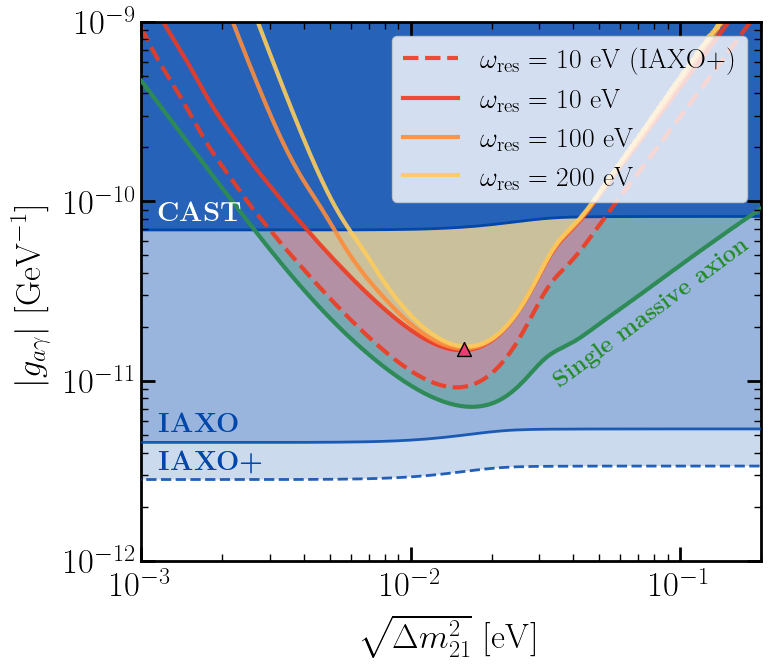

In [5]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":25,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

gs = gridspec.GridSpec(1,1,wspace=0.0)
fig = plt.figure()
ax = fig.add_subplot(gs[0])
ax.set_xlim(left=1e-3,right=2e-1)
ax.set_ylim(bottom=1e-12,top=1e-9)
ax.tick_params(axis='x',which='major',pad=8)
ax.tick_params(axis='x',which='minor',pad=8)
ax.set_xlabel(r"$\sqrt{\Delta m_{21}^2}\ [\mathrm{eV}]$",labelpad=10)
ax.set_ylabel(r"$|g_{a\gamma}|\ [\mathrm{GeV}^{-1}]$",labelpad=10)

folder1 = "input_data"
folder2 = "results_data"
reds = YlOrRd_5.mpl_colors
bolds = Bold_10.mpl_colors

# Exclusion limit CAST @95 CL
CAST = np.loadtxt(os.path.join(folder1,"CAST_exclusion.dat"))
x_CAST = CAST[:,0]
g_excl_CAST = CAST[:,1]
plt.loglog(x_CAST,g_excl_CAST,color="#0047AB",zorder=1)
ax.fill_between(x_CAST,g_excl_CAST,ax.get_ylim()[1],facecolor="#0047AB",zorder=0.5,alpha=0.85)
ax.text(1.15e-3,7.8e-11,r'{\bf CAST}',fontsize=20,color='w',zorder=1000)

# Exclusion limit IAXO @95 CL
IAXO = np.loadtxt(os.path.join(folder1,"IAXO_projection.dat"))
x_IAXO = IAXO[:,0]
g_excl_IAXO = IAXO[:,1]
plt.loglog(x_IAXO,g_excl_IAXO,color="#0047AB",zorder=8,alpha=0.85)
ax.fill_between(x_IAXO,g_excl_IAXO,g_excl_CAST,facecolor="#0047AB",zorder=0.05,alpha=0.4)
ax.text(1.15e-3,5.2e-12,r'{\bf IAXO}',fontsize=20,color="#0047AB",zorder=1000)

# Exclusion limit IAXOplus @95 CL
IAXOplus = np.loadtxt(os.path.join(folder1,"IAXOplus_projection.dat"))
x_IAXOplus = IAXOplus[:,0]
g_excl_IAXOplus = IAXOplus[:,1]
plt.loglog(x_IAXOplus,g_excl_IAXOplus,color="#0047AB",ls='--',zorder=8,alpha=0.85)
ax.fill_between(x_IAXOplus,g_excl_IAXOplus,g_excl_IAXO,facecolor="#0047AB",zorder=0.05,alpha=0.2)
ax.text(1.15e-3,3.2e-12,r'{\bf IAXO+}',fontsize=20,color="#0047AB",zorder=1000)

# Discovery limit IAXOplus (w_res = 10 eV)
IAXOplus_10eV = np.loadtxt(os.path.join(folder2,"Hierarchical","Hierarchical_IAXOplus_disc_10eV.dat"))
x_IAXOplus_10eV = IAXOplus_10eV[:,0]
g_disc_IAXOplus_10eV = IAXOplus_10eV[:,1]
plt.loglog(x_IAXOplus_10eV,g_disc_IAXOplus_10eV,color=reds[3],lw=3,ls='--',label=r'$\omega_\mathrm{res} = 10\ \mathrm{eV}\ (\mathrm{IAXO}+)$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 10 eV)
IAXO_10eV = np.loadtxt(os.path.join(folder2,"Hierarchical","Hierarchical_IAXO_disc_10eV.dat"))
x_IAXO_10eV = IAXO_10eV[:,0]
g_disc_IAXO_10eV = IAXO_10eV[:,1]
plt.loglog(x_IAXO_10eV,g_disc_IAXO_10eV,color=reds[3],lw=3,label=r'$\omega_\mathrm{res} = 10\ \mathrm{eV}$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 100 eV)
IAXO_100eV = np.loadtxt(os.path.join(folder2,"Hierarchical","Hierarchical_IAXO_disc_100eV.dat"))
x_IAXO_100eV = IAXO_100eV[:,0]
g_disc_IAXO_100eV = IAXO_100eV[:,1]
plt.loglog(x_IAXO_100eV,g_disc_IAXO_100eV,color=reds[2],lw=3,label=r'$\omega_\mathrm{res} = 100\ \mathrm{eV}$',zorder=2,alpha=0.9)

# Discovery limit IAXO (w_res = 200 eV)
IAXO_200eV = np.loadtxt(os.path.join(folder2,"Hierarchical","Hierarchical_IAXO_disc_200eV.dat"))
x_IAXO_200eV = IAXO_200eV[:,0]
g_disc_IAXO_200eV = IAXO_200eV[:,1]
plt.loglog(x_IAXO_200eV,g_disc_IAXO_200eV,color=reds[1],lw=3,label=r'$\omega_\mathrm{res} = 200\ \mathrm{eV}$',zorder=2,alpha=0.9)

# Single massive axion (w_res = 100 eV): from arXiv:1811.09290
single_axion = np.loadtxt(os.path.join(folder2,"Hierarchical","MassDiscoveryLimit_Photon.txt"))
x_single_axion = single_axion[0,:]
g_disc_single_axion = single_axion[4,:]
plt.loglog(x_single_axion,g_disc_single_axion,color="seagreen",lw=3,zorder=9,alpha=0.995)
ax.text(3.3e-2,0.93e-11,r'{\bf Single massive axion}',fontsize=17,color='forestgreen',zorder=1000,rotation=36.5)

# Relevant points
x1_val = 1.57e-2 # [eV]
y1_val = 1.5e-11 # [GeV^-1]
ax.scatter(x1_val,y1_val,color=bolds[4],s=100,zorder=50,marker='^',edgecolor='black')

# Distinction regions
logg_CAST_on_IAXO_10eV = np.interp(np.log10(x_IAXO_10eV),np.log10(x_CAST),np.log10(g_excl_CAST))
g_CAST_on_IAXO_10eV = 10**logg_CAST_on_IAXO_10eV
mask = g_CAST_on_IAXO_10eV > g_disc_IAXO_10eV
ax.fill_between(
    x_IAXO_10eV,
    g_disc_IAXO_10eV,
    g_CAST_on_IAXO_10eV,
    where=mask,
    facecolor=reds[1],
    interpolate=True,
    alpha=0.5,
    zorder=0.1           
)

def interp_loglog(x_new,x,y):
    return 10**np.interp(np.log10(x_new),np.log10(x),np.log10(y))
xmin = max(x_CAST.min(),x_IAXO_10eV.min(),x_IAXOplus_10eV.min())
xmax = min(x_CAST.max(),x_IAXO_10eV.max(),x_IAXOplus_10eV.max())
x_common = np.logspace(np.log10(xmin),np.log10(xmax),2000)
gCAST = interp_loglog(x_common,x_CAST,g_excl_CAST)
gIAXO = interp_loglog(x_common,x_IAXO_10eV,g_disc_IAXO_10eV)
gIAXOp = interp_loglog(x_common,x_IAXOplus_10eV,g_disc_IAXOplus_10eV)
g_bottom = np.minimum(gIAXO,gIAXOp)
g_top = np.minimum(gIAXO,gCAST)
mask = g_top > g_bottom
ax.fill_between(
    x_common,
    g_bottom,
    g_top,
    where=mask,
    interpolate=True,
    facecolor=reds[3],
    alpha=0.3,
    zorder=0.3
)

xmin = max(x_CAST.min(),x_IAXOplus_10eV.min(),x_single_axion.min())
xmax = min(x_CAST.max(),x_IAXOplus_10eV.max(),x_single_axion.max())
x_common = np.logspace(np.log10(xmin),np.log10(xmax),2000)
gCAST = interp_loglog(x_common,x_CAST,g_excl_CAST)
gIAXOp = interp_loglog(x_common,x_IAXOplus_10eV,g_disc_IAXOplus_10eV)
gsingle = interp_loglog(x_common,x_single_axion,g_disc_single_axion)
g_bottom = gsingle
g_top = np.minimum(gCAST,gIAXOp)
mask = g_top > g_bottom
ax.fill_between(
    x_common,
    g_bottom,
    g_top,
    where=mask,
    interpolate=True,
    facecolor="seagreen",
    alpha=0.3,
    zorder=0.3
)

ax.xaxis.set_zorder(1000)
ax.yaxis.set_zorder(1000)
leg = ax.legend(fontsize=20,loc='upper right')
leg.set_zorder(2000)

fig.savefig("plots/Hierarchical_disc.pdf",bbox_inches="tight")
fig.savefig("plots/Hierarchical_disc.png",bbox_inches="tight")
plt.show()

In [1]:
# BabyIAXO quasi-degenerate
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, BabyIAXO, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

q0 = 9.0 # 3-sigma discovery limit
m2 = 1e-3 # [eV]
g_arb = 1.0e-11 # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
res_on = True


delta_m21_sq_vals = np.logspace(-18.0,np.log10(4e-10),1000) # [eV^2]
x = np.sqrt(delta_m21_sq_vals)
g_disc_BabyIAXO_100eV = np.empty_like(delta_m21_sq_vals,dtype=float)

N_bins = 200
w_res = 100e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    g_disc_BabyIAXO_100eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,BabyIAXO["B"],BabyIAXO["L"],L_source,BabyIAXO["S"],BabyIAXO["t"],BabyIAXO["eps_T"],BabyIAXO["eps_D"],
                                           w_min,w_max,N_bins,
                                           res_on=res_on,w_res=w_res,
                                           m2_bounds=(m2,m2))

np.savetxt("results_data/Quasi-degenerate/Quasideg_BabyIAXO_discovery_100eV.dat",
           np.column_stack((x,g_disc_BabyIAXO_100eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_BabyIAXO [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")


In [3]:
# BabyIAXO hierarchical
import numpy as np
from Functions_Binned_Analysis import Discovery_Limit, BabyIAXO, L_ES
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

q0 = 9.0 # 3-sigma discovery limit
g_arb = 1.0e-11 # [GeV^-1]
mixing = np.pi/4.0
L_source = L_ES
w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
res_on = True
m2_bounds=(1e-9,1e0)

delta_m21_sq_vals = np.logspace(-6.0,np.log10(4e-2),1000) # [eV^2]
x = np.sqrt(delta_m21_sq_vals)
g_disc_BabyIAXO_100eV = np.empty_like(delta_m21_sq_vals,dtype=float)

N_bins = 200
w_res = 100e-3 # [keV]
for k,dm2 in enumerate(delta_m21_sq_vals):
    m2 = (1+1e-10)*np.sqrt(dm2)
    g_disc_BabyIAXO_100eV[k] = Discovery_Limit(q0,g_arb,m2,dm2,mixing,BabyIAXO["B"],BabyIAXO["L"],L_source,BabyIAXO["S"],BabyIAXO["t"],BabyIAXO["eps_T"],BabyIAXO["eps_D"],
                                           w_min,w_max,N_bins,
                                           res_on=res_on,w_res=w_res,
                                           m2_bounds=m2_bounds)

np.savetxt("results_data/Hierarchical/Hierarchical_BabyIAXO_discovery_100eV.dat",
           np.column_stack((x,g_disc_BabyIAXO_100eV)),
           fmt="%.6e",
           header="sqrt(Delta_m21^2) [eV]    g_BabyIAXO [GeV^-1]    (varphi = pi/4, w_res = 100 eV)")
